In [1]:
# =====================================================
# BI-LSTM + FASTTEXT INDONESIA (PYTORCH VERSION) + PROGRESS BAR
# =====================================================

import re
import html
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    roc_curve, auc
)

# Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# =====================================================
# DEVICE SETUP
# =====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.backends.cudnn.enabled = False
torch.backends.cudnn.benchmark = False

Using device: cuda


Preprocessing...


100%|██████████| 3523/3523 [02:44<00:00, 21.48it/s]


Vocab size: 23479
Loading FastText (hemat RAM mode)...
Found words: 15093
Coverage: 0.6428297627667278
embedding jadi tensor
svmem(total=16390729728, available=7518326784, percent=54.1, used=8872402944, free=7518326784)
model berhasil dibuat
model sudah pindah device
Testing dummy forward...
Forward OK, output shape: torch.Size([2])
🚀 Training dengan Early Stopping (monitor = Val F1)...


Epoch 1/20
Train Loss: 0.3199
Validation F1: 0.9074
✅ Model terbaik (di memory) diperbarui


Epoch 2/20
Train Loss: 0.2252
Validation F1: 0.9148
✅ Model terbaik (di memory) diperbarui


...

Epoch 11/20
Train Loss: 0.0754
Validation F1: 0.9308
⚠️ Tidak ada peningkatan F1 (2/5)


Epoch 12/20
Train Loss: 0.0680
Validation F1: 0.9295
⚠️ Tidak ada peningkatan F1 (3/5)


Epoch 13/20
Train Loss: 0.0584
Validation F1: 0.9292
⚠️ Tidak ada peningkatan F1 (4/5)


Epoch 14/20
Train Loss: 0.0523
Validation F1: 0.9317
⚠️ Tidak ada peningkatan F1 (5/5)
🛑 Early stopping triggered!
✅ Training selesai



=== FINAL TEST EVALUATION ===
Accuracy : 0.8830542151575362
Precision: 0.6670951156812339
Recall   : 0.7723214285714286
F1-score : 0.7158620689655173
AUC      : 0.9208089058141672

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9443    0.9092    0.9264      2851
           1     0.6671    0.7723    0.7159       672

    accuracy                         0.8831      3523
   macro avg     0.8057    0.8407    0.8211      3523
weighted avg     0.8914    0.8831    0.8862      3523

=== CONFUSION MATRIX ===
[[2592  259]
 [ 153  519]]


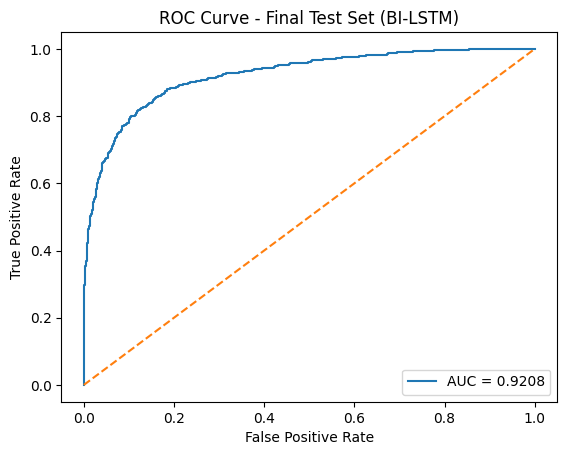

In [2]:
# =====================================================
# PREPROCESSING
# =====================================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stop_words_id = set(stop_factory.get_stop_words())

protected_stopwords = {
    'tidak','tidakkah','tidaklah','tak','bukan','bukankah','bukanlah','bukannya','tanpa','belum','belumlah',
    'jangan','janganlah','jangankan','enggak','enggaknya','aku','akulah','saya','sayalah','kami','kamilah',
    'kita','kitalah','kamu','kamulah','anda','andalah','dia','dialah','ia','ialah','mereka','merekalah',
    'apa','apaan','apakah','apatah','bagaimana','bagaimanakah','berapa','berapakah','berapalah','bilakah',
    'kapan','kapankah','kenapa','mengapa','siapa','siapakah','siapapun','mana','bisakah','bolehkah',
    'bolehlah','perlukah','mungkinkah','haruskah','benarkah','sudahkah','tapi','tetapi','namun','melainkan',
    'padahal','walau','walaupun','meski','meskipun','sebaliknya','malah','malahan'
}
final_stopwords = stop_words_id - protected_stopwords

def preprocess_text(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = html.unescape(text)
    text = re.sub(r'[^a-zA-Z#\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [t for t in tokens if t not in final_stopwords]
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens

# =====================================================
# LOAD DATA
# =====================================================

dataset_a = pd.read_csv("smote_100.csv")
dataset_b = pd.read_csv("data_20.csv")

X_a = dataset_a["Text"]
y_a = dataset_a["label"]

X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_a, y_a,
    test_size=0.125,
    random_state=42,
    stratify=y_a
)

X_test_text = dataset_b["Text"]
y_test = dataset_b["label"]

print("Preprocessing...")
X_train_tokens = [preprocess_text(t) for t in tqdm(X_train_text)]
X_val_tokens   = [preprocess_text(t) for t in tqdm(X_val_text)]
X_test_tokens  = [preprocess_text(t) for t in tqdm(X_test_text)]

# =====================================================
# BUILD VOCAB
# =====================================================

word_index = {}
for tokens in X_train_tokens:
    for word in tokens:
        if word not in word_index:
            word_index[word] = len(word_index) + 1

vocab_size = len(word_index) + 1
print("Vocab size:", vocab_size)

# =====================================================
# LOAD FASTTEXT DARI FILE LOKAL (HEMAT RAM)
# =====================================================

embedding_dim = 300
fasttext_path = r"C:\SKRIPSI BRYAN\cc.id.300.vec"

print("Loading FastText (hemat RAM mode)...")

embedding_matrix = np.random.normal(
    scale=0.6,
    size=(vocab_size, embedding_dim)
)

found_words = 0

with open(fasttext_path, 'r', encoding='utf-8', newline='\n', errors='ignore') as f:
    next(f)  # skip header

    for line in f:
        values = line.rstrip().split(' ')
        word = values[0]

        if word in word_index:
            vector = np.asarray(values[1:], dtype='float32')
            idx = word_index[word]
            embedding_matrix[idx] = vector
            found_words += 1

print("Found words:", found_words)
print("Coverage:", found_words / vocab_size)

embedding_matrix = torch.tensor(embedding_matrix, dtype=torch.float32)

print("embedding jadi tensor")

def texts_to_sequences(token_list):
    return [[word_index.get(w, 0) for w in tokens] for tokens in token_list]

X_train_seq = texts_to_sequences(X_train_tokens)
X_val_seq   = texts_to_sequences(X_val_tokens)
X_test_seq  = texts_to_sequences(X_test_tokens)

# =====================================================
# PADDING
# =====================================================

max_len = 50

def pad_sequences(sequences):
    padded = np.zeros((len(sequences), max_len))
    for i, seq in enumerate(sequences):
        seq = seq[:max_len]
        padded[i, :len(seq)] = seq
    return padded

X_train_pad = pad_sequences(X_train_seq)
X_val_pad   = pad_sequences(X_val_seq)
X_test_pad  = pad_sequences(X_test_seq)

import psutil
print(psutil.virtual_memory())

# =====================================================
# DATASET CLASS
# =====================================================

class TextDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TextDataset(X_train_pad, y_train), batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(TextDataset(X_val_pad, y_val), batch_size=16, num_workers=0)
test_loader  = DataLoader(TextDataset(X_test_pad, y_test), batch_size=16, num_workers=0)

# =====================================================
# MODEL
# =====================================================

class BiLSTM(nn.Module):
    def __init__(self):
        super(BiLSTM, self).__init__()
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=True
        )
        self.lstm = nn.LSTM(
            embedding_dim,
            32,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        out = self.fc(hidden)
        return out.squeeze()

print("model berhasil dibuat")

model = BiLSTM().to(device)

print("model sudah pindah device")

print("Testing dummy forward...")

dummy = torch.randint(0, vocab_size, (2, 50)).to(device)
out = model(dummy)

print("Forward OK, output shape:", out.shape)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# =====================================================
# TRAINING LOOP + PROGRESS BAR
# =====================================================

import copy

epochs = 20
patience = 5
best_f1 = 0
counter = 0
best_model_state = None

print("🚀 Training dengan Early Stopping (monitor = Val F1)...")

for epoch in range(epochs):
    model.train()
    total_loss = 0

    # ========== TRAINING ==========
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training", leave=False)
    for X_batch, y_batch in train_loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_loop.set_postfix(loss=loss.item())

    # ========== VALIDATION ==========
    model.eval()
    val_preds = []
    val_true = []

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation", leave=False)
    with torch.no_grad():
        for X_batch, y_batch in val_loop:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).cpu().numpy()

            val_preds.extend(preds)
            val_true.extend(y_batch.numpy())

    val_f1 = f1_score(val_true, val_preds)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {total_loss/len(train_loader):.4f}")
    print(f"Validation F1: {val_f1:.4f}")

    # ================= EARLY STOPPING =================
    if val_f1 > best_f1:
        best_f1 = val_f1
        counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print("✅ Model terbaik (di memory) diperbarui")
    else:
        counter += 1
        print(f"⚠️ Tidak ada peningkatan F1 ({counter}/{patience})")

        if counter >= patience:
            print("🛑 Early stopping triggered!")
            break

print("✅ Training selesai")

# =====================================================
# EVALUATION
# =====================================================

model.load_state_dict(best_model_state)
model.eval()
all_preds = []
all_probs = []

test_loop = tqdm(test_loader, desc="Testing", leave=False)
with torch.no_grad():
    for X_batch, _ in test_loop:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend((probs >= 0.5).cpu().numpy())

y_pred = np.array(all_preds)
y_proba = np.array(all_probs)

print("\n=== FINAL TEST EVALUATION ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("AUC      :", roc_auc_score(y_test, y_proba))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Test Set (BI-LSTM)")
plt.legend(loc="lower right")
plt.show()